In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
test_path = '/kaggle/input/competitions/titanic/test.csv'
train_path = '/kaggle/input/competitions/titanic/train.csv'

train_data = pd.read_csv(train_path)
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"학습 데이터 수: {len(X_train)}")
print(f"검증 데이터 수: {len(X_val)}")

학습 데이터 수: 712
검증 데이터 수: 179


Text(0, 0.5, 'Percentage')

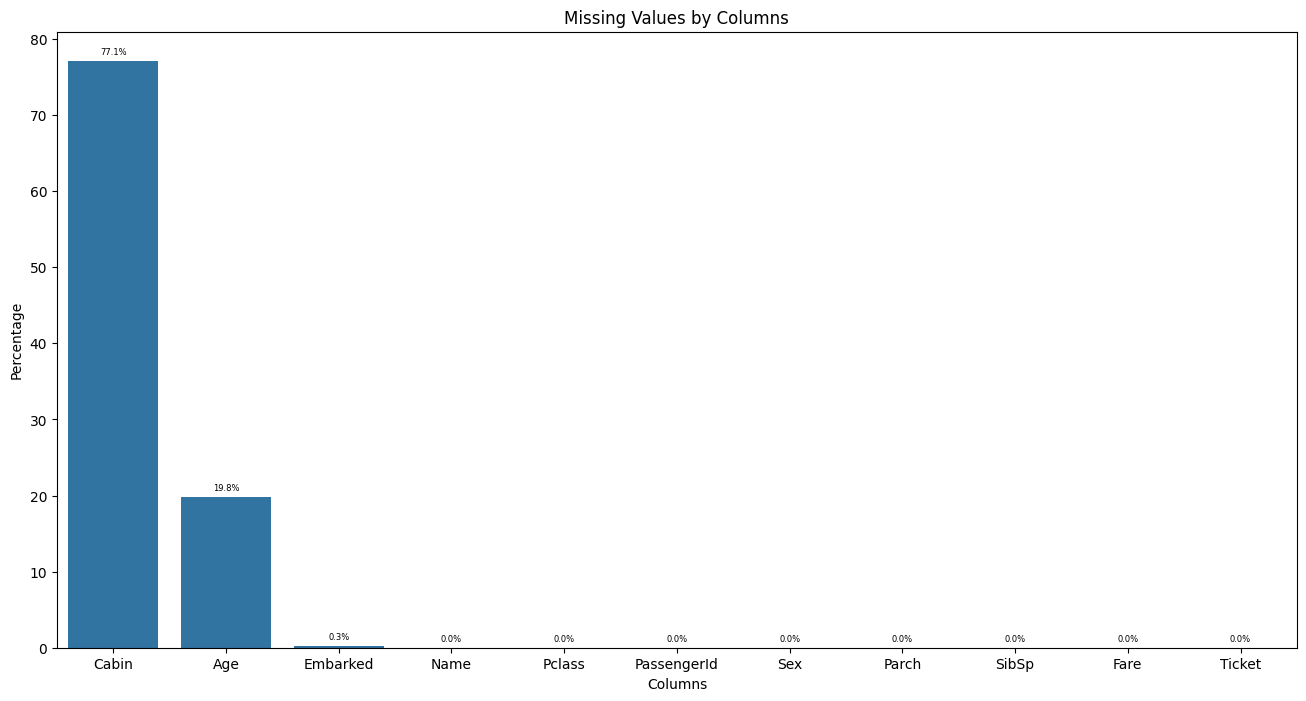

In [4]:
null_percent = X_train.isnull().mean()*100

nulls = null_percent.sort_values(ascending=False)

plt.figure(figsize=(16,8))

ax = sns.barplot(x=nulls.index, y=nulls.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)

plt.title("Missing Values by Columns")
plt.xlabel("Columns")
plt.ylabel("Percentage")

In [5]:
# Cabin은 결측치 매우 높으므로 삭제
# Age는 호칭별 중앙값으로 대치
# Embarked는 대치 또는 행 삭제 중 고려

In [6]:
# 상수 열 확인
n_unique = X_train.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수열 개수: {len(constant_cols)}")
print(f"상수열 목록: {constant_cols.tolist()}")

상수열 개수: 0
상수열 목록: []


In [7]:
# Cabin열 삭제
train_dropped = X_train.drop(columns='Cabin')
valid_dropped = X_val.drop(columns='Cabin')
print(f"Cabin 삭제 후 학습 데이터 cloumns 수: {len(train_dropped.columns)}")
print(f"Cabin 삭제 후 검증 데이터 cloumns 수: {len(valid_dropped.columns)}")


# Age열 대체(Name의 호칭 별 중앙값으로 대체)
# 호칭(Title) 추출
train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
valid_dropped['Title'] = valid_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 호칭별 나이 중앙값 계산
title_age_map = train_dropped.groupby('Title')['Age'].median()

# Age 결측치 호칭별 중앙값으로 대체
train_dropped['Age'] = train_dropped['Age'].fillna(train_dropped['Title'].map(title_age_map))
valid_dropped['Age'] = valid_dropped['Age'].fillna(valid_dropped['Title'].map(title_age_map))

# 확인
print(train_dropped[['Name', 'Title', 'Age']].head(10))
print(valid_dropped[['Name', 'Title', 'Age']].head(10))

# Embarked 결측 행 삭제
print(f"학습 데이터 Embarked 결측행 수: {train_dropped.isnull().sum().sum()}")
print(f"검증 데이터 Embarked 결측행 수: {valid_dropped.isnull().sum().sum()}")
train_dropped2 = train_dropped.dropna(subset=['Embarked'])
valid_dropped2 = valid_dropped.dropna(subset=['Embarked'])
print(f"학습 데이터 Embarked 결측행 삭제 전 열 수: {len(train_dropped)}")
print(f"검증 데이터 Embarked 결측행 삭제 전 열 수: {len(valid_dropped)}")
print(f"학습 데이터 Embarked 결측행 삭제 후 열 수: {len(train_dropped2)}")
print(f"검증 데이터 Embarked 결측행 삭제 후 열 수: {len(valid_dropped2)}")

# 최종 점검
print(f"학습 데이터 최종 결측치 수: {train_dropped2.isnull().sum().sum()}")
print(f"검증 데이터 최종 결측치 수: {valid_dropped2.isnull().sum().sum()}")

Cabin 삭제 후 학습 데이터 cloumns 수: 10
Cabin 삭제 후 검증 데이터 cloumns 수: 10
                                       Name Title   Age
140           Boulos, Mrs. Joseph (Sultana)   Mrs  35.0
439  Kvillner, Mr. Johan Henrik Johannesson    Mr  31.0
817                      Mallet, Mr. Albert    Mr  31.0
378                     Betros, Mr. Tannous    Mr  20.0
491                     Windelov, Mr. Einar    Mr  21.0
331                     Partner, Mr. Austen    Mr  45.5
588                   Gilinski, Mr. Eliezer    Mr  22.0
358                    McGovern, Miss. Mary  Miss  21.0
674              Watson, Mr. Ennis Hastings    Mr  30.0
162              Bengtsson, Mr. John Viktor    Mr  26.0
                                               Name   Title   Age
495                           Yousseff, Mr. Gerious      Mr  30.0
648                              Willey, Mr. Edward      Mr  30.0
278                              Rice, Master. Eric  Master   7.0
31   Spencer, Mrs. William Augustus (Marie Eugenie)     

<>:10: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_17/3679605439.py:10: SyntaxWarning: invalid escape sequence '\.'
  train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipykernel_17/3679605439.py:11: SyntaxWarning: invalid escape sequence '\.'
  valid_dropped['Title'] = valid_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


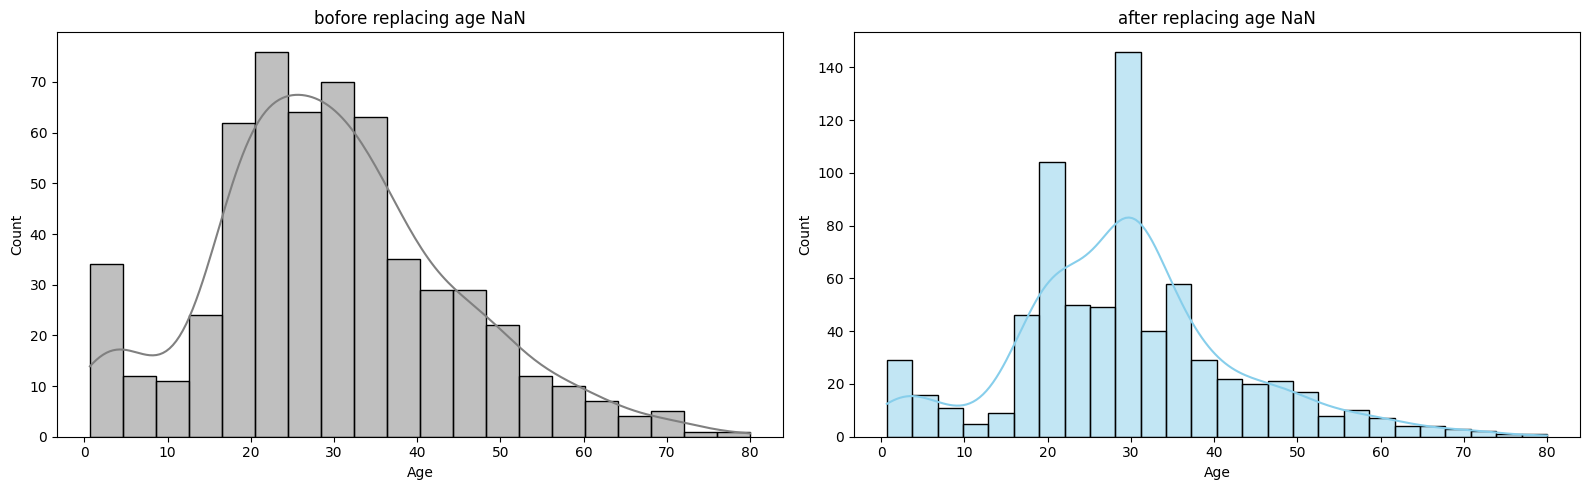

In [8]:
# 대체 후 분포 변화 확인
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(X_train['Age'], kde=True, ax=axes[0], color='gray')
axes[0].set_title("bofore replacing age NaN")

sns.histplot(train_dropped['Age'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title("after replacing age NaN")

plt.tight_layout()
plt.show()

In [9]:
# 분포가 많이 변했지만, 자연스러운 현상이라 봄
# 호칭별 중앙값으로 대체했으니, 정교하게 잘 대체됐다 볼 수 있음

In [10]:
# 문자 데이터 확인

categorical_cols1 = [col for col in train_dropped2.columns if train_dropped2[col].dtype == "object"]
print(categorical_cols1)
for i in categorical_cols1:
    print(f"{i}: {train_dropped2[i].nunique()}\n")
    print(f"{i}: {train_dropped2[i].value_counts()}\n")

categorical_cols2 = [col for col in valid_dropped2.columns if valid_dropped2[col].dtype == "object"]
print(categorical_cols2)
for i in categorical_cols2:
    print(f"{i}: {valid_dropped2[i].nunique()}\n")
    print(f"{i}: {valid_dropped2[i].value_counts()}\n")

['Name', 'Sex', 'Ticket', 'Embarked', 'Title']
Name: 710

Name: Name
Brown, Mr. Thomas William Solomon         1
Boulos, Mrs. Joseph (Sultana)             1
Kvillner, Mr. Johan Henrik Johannesson    1
Mallet, Mr. Albert                        1
Betros, Mr. Tannous                       1
                                         ..
Christy, Miss. Julie Rachel               1
Bengtsson, Mr. John Viktor                1
Watson, Mr. Ennis Hastings                1
McGovern, Miss. Mary                      1
Gilinski, Mr. Eliezer                     1
Name: count, Length: 710, dtype: int64

Sex: 2

Sex: Sex
male      465
female    245
Name: count, dtype: int64

Ticket: 568

Ticket: Ticket
CA. 2343    7
347082      6
CA 2144     5
1601        5
17421       4
           ..
349244      1
PC 17595    1
244367      1
349213      1
250649      1
Name: count, Length: 568, dtype: int64

Embarked: 3

Embarked: Embarked
S    517
C    129
Q     64
Name: count, dtype: int64

Title: 15

Title: Title
Mr 

In [11]:
# Name, Ticket: 이름은 이미 title로 뽑아냈고, 티켓번호는 양이 너무 많고, 생존 유무에 크게 으미 없다고 판단 -> 제거
# Sex, Embarked: 고유값이 매우 적고 명확 -> One-Hot Encoding
# Title: 15개의 고유값을 갖지만, 대부분이 Mr, Miss, Mrs, Master 4종류임. 나머지는 Other로 분류 -> One-Hot Encoding

In [12]:
# Name, Ticket 삭제
cols_to_drop = ['Name', 'Ticket']
train_dropped3 = train_dropped2.drop(columns=cols_to_drop)
valid_dropped3 = valid_dropped2.drop(columns=cols_to_drop)

print(f"훈련 데이터 열: {train_dropped3.columns.tolist()}\n검증 데이터 열: {valid_dropped3.columns.tolist()}")

# Title 분류
target_title = ['Mr','Miss','Mr','Master']

train_dropped3['Title'] = train_dropped3['Title'].apply(lambda x: x if x in target_title else 'others')
valid_dropped3['Title'] = valid_dropped3['Title'].apply(lambda x: x if x in target_title else 'others')

# Sex, Embarked, Title 인코딩

from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['Sex','Embarked','Title']

ohencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

oh_cols_train = pd.DataFrame(ohencoder.fit_transform(train_dropped3[cols_to_encode]))
oh_cols_valid = pd.DataFrame(ohencoder.transform(valid_dropped3[cols_to_encode]))

oh_cols_train.index = train_dropped3.index
oh_cols_valid.index = valid_dropped3.index

num_X_train = train_dropped3.drop(cols_to_encode, axis=1)
num_X_valid = valid_dropped3.drop(cols_to_encode, axis=1)

oh_X_train = pd.concat([num_X_train, oh_cols_train], axis=1)
oh_X_valid = pd.concat([num_X_valid, oh_cols_valid], axis=1)

oh_X_train.columns = oh_X_train.columns.astype(str)
oh_X_valid.columns = oh_X_valid.columns.astype(str)

# 확인
train_object_cols = [col for col in oh_X_train.columns if oh_X_train[col].dtype == 'object']
valid_object_cols = [col for col in oh_X_valid.columns if oh_X_valid[col].dtype == 'object']
print(f"훈련 데이터 categorical values 수: {len(train_object_cols)}")
print(f"검증 데이터 categorical values 수: {len(valid_object_cols)}")

oh_X_train.head()

훈련 데이터 열: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
검증 데이터 열: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
훈련 데이터 categorical values 수: 0
검증 데이터 categorical values 수: 0


,PassengerId,Pclass,Age,SibSp,Parch,Fare,0,1,2,3,4,5,6,7,8
140,141,3,35.0,0,2,15.2458,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
439,440,2,31.0,0,0,10.5000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
817,818,2,31.0,1,1,37.0042,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
378,379,3,20.0,0,0,4.0125,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
491,492,3,21.0,0,0,7.2500,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [13]:
# y데이터 행 일치
y_train_final = y_train.loc[oh_X_train.index]
y_val_final = y_val.loc[oh_X_valid.index]

print("학습 데이터 shape:", oh_X_train.shape, y_train_final.shape)
print("검증 데이터 shape:", oh_X_valid.shape, y_val_final.shape)

학습 데이터 shape: (710, 15) (710,)
검증 데이터 shape: (179, 15) (179,)
